# ✏️ Stroke Extraction — Dotted Tracing Guide
Extracts evenly-spaced guide dots from **line-art OR color** images.

**Key fix vs previous version:** dots are now placed at a fixed pixel spacing along the stroke's arc length — so every stroke appears as a proper dotted line, not just start + end.

| Mode | Image type | Binarization |
|---|---|---|
| `lineart` | Black lines on white background | Brightness threshold + invert |
| `color` | Colored fills + dark outlines | HSV Value channel extraction |

In [1]:
!pip install scikit-image opencv-python-headless numpy matplotlib networkx --quiet

## ⚙️ Config

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [13]:
#INPUT_IMAGE   = "/content/drive/MyDrive/raw_building.jpeg"   # Path to your line-art image
INPUT_IMAGE   = "/content/drive/MyDrive/color_img.jpeg"

# "auto" | "lineart" | "color"
IMAGE_MODE    = "auto"

# ── Lineart settings ───────────────────────────
THRESH_VALUE  = 200    # Brightness cutoff. Darker pixels become lines.

# ── Color settings ─────────────────────────────
DARK_THRESH   = 60     # HSV Value cutoff. Pixels darker than this = outline.
                       # Raise to 80–100 if outlines look gray/dark-brown.

# ── Dot placement ──────────────────────────────
DOT_SPACING   = 15     # Pixels between each guide dot along the stroke path.
                       # Lower = more dots (denser). Higher = fewer dots (sparser).
                       # Try 10 for detailed small images, 20–30 for large images.

MIN_STROKE_PX = 10     # Skip skeleton strokes shorter than this (noise removal)
OUTPUT_JSON   = "strokes.json"

## Step 1 — Load & detect mode

In [14]:
import cv2, json
import numpy as np
import matplotlib, matplotlib.pyplot as plt
from skimage.morphology import skeletonize
import networkx as nx

img_bgr = cv2.imread(INPUT_IMAGE)
assert img_bgr is not None, f"Cannot load: {INPUT_IMAGE}"
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
gray    = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
hsv     = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
H, W    = gray.shape
print(f"Image: {W}x{H} px")

def auto_detect_mode(bgr):
    g   = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
    sat = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)[:,:,1].mean()
    _, bright = cv2.threshold(g, 240, 255, cv2.THRESH_BINARY)
    white_ratio = np.count_nonzero(bright) / g.size
    print(f"  Saturation mean : {sat:.1f}")
    print(f"  White ratio     : {white_ratio:.1%}")
    return "lineart" if (sat < 15 and white_ratio > 0.5) else "color"

mode = auto_detect_mode(img_bgr) if IMAGE_MODE == "auto" else IMAGE_MODE
print(f"  → Mode: {mode.upper()}")

Image: 1024x706 px
  Saturation mean : 65.4
  White ratio     : 40.3%
  → Mode: COLOR


## Step 2 — Binarize

Strategy  : HSV Value channel (dark pixels < 60)
Line px   : 70,960 / 722,944  (9.8%)


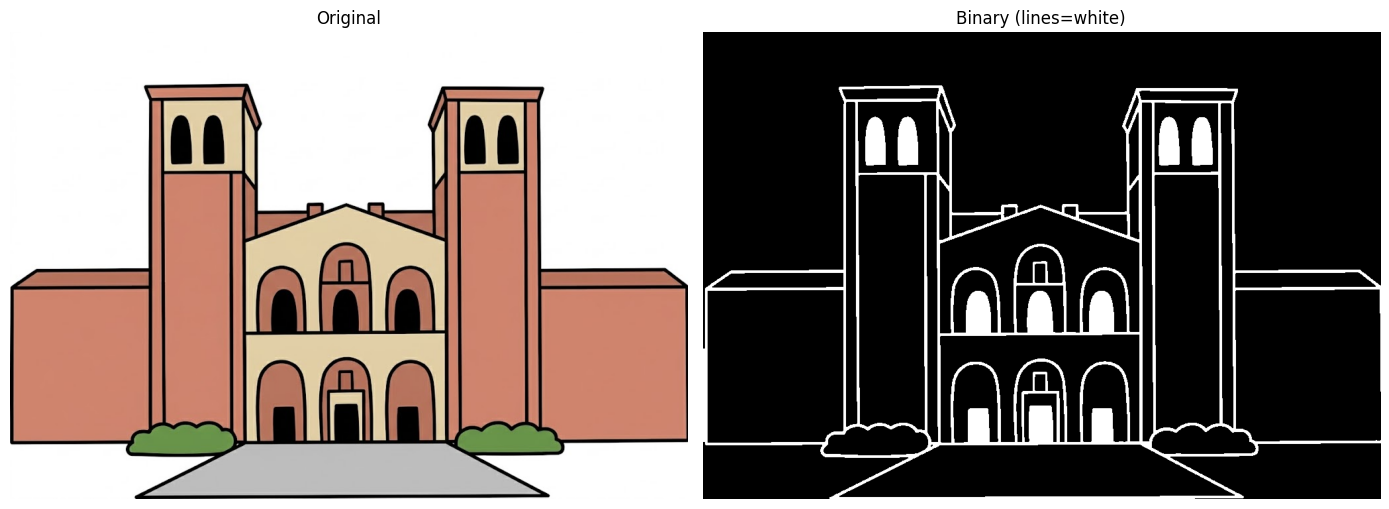

In [15]:
k2 = np.ones((2,2), np.uint8)

if mode == "lineart":
    blur = cv2.GaussianBlur(gray, (3,3), 0)
    _, binary = cv2.threshold(blur, THRESH_VALUE, 255, cv2.THRESH_BINARY_INV)
    binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, k2)
    label  = f"Brightness threshold (inverted, cutoff={THRESH_VALUE})"
else:
    # HSV Value isolates near-black outline pixels regardless of fill color.
    # Old brightness approach grabbed colored fills too (51% of pixels).
    # This gets only the dark outlines (≈9% of pixels).
    _, binary = cv2.threshold(hsv[:,:,2], DARK_THRESH, 255, cv2.THRESH_BINARY_INV)
    binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, k2)
    binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN,  k2)
    label  = f"HSV Value channel (dark pixels < {DARK_THRESH})"

pct = np.count_nonzero(binary) / (W * H)
print(f"Strategy  : {label}")
print(f"Line px   : {np.count_nonzero(binary):,} / {W*H:,}  ({pct:.1%})")
if pct > 0.3:
    print("⚠️  >30% selected — likely capturing fills. Lower DARK_THRESH or THRESH_VALUE.")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(img_rgb);             axes[0].set_title("Original");          axes[0].axis("off")
axes[1].imshow(binary, cmap="gray"); axes[1].set_title("Binary (lines=white)"); axes[1].axis("off")
plt.tight_layout(); plt.show()

## Step 3 — Skeletonize

Skeleton pixels: 12,016


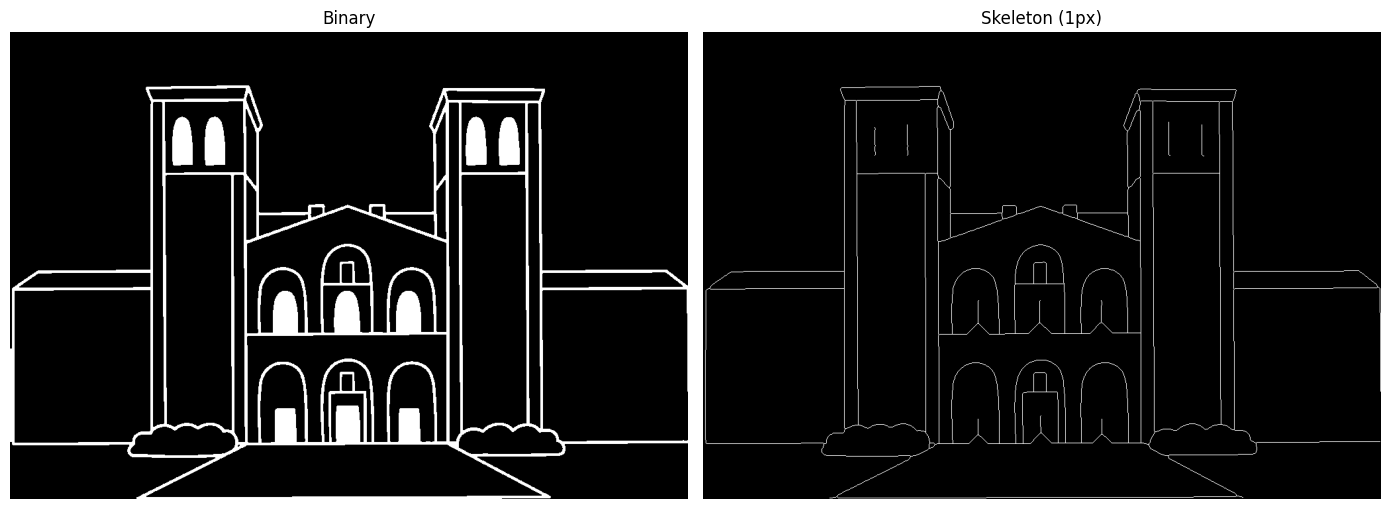

In [16]:
skeleton = skeletonize(binary // 255).astype(np.uint8) * 255
print(f"Skeleton pixels: {np.count_nonzero(skeleton):,}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(binary,   cmap="gray"); axes[0].set_title("Binary");          axes[0].axis("off")
axes[1].imshow(skeleton, cmap="gray"); axes[1].set_title("Skeleton (1px)"); axes[1].axis("off")
plt.tight_layout(); plt.show()

## Step 4 — Build pixel graph

Nodes: 12,016  |  Edges: 12,172
Endpoints: 18   Junctions: 280


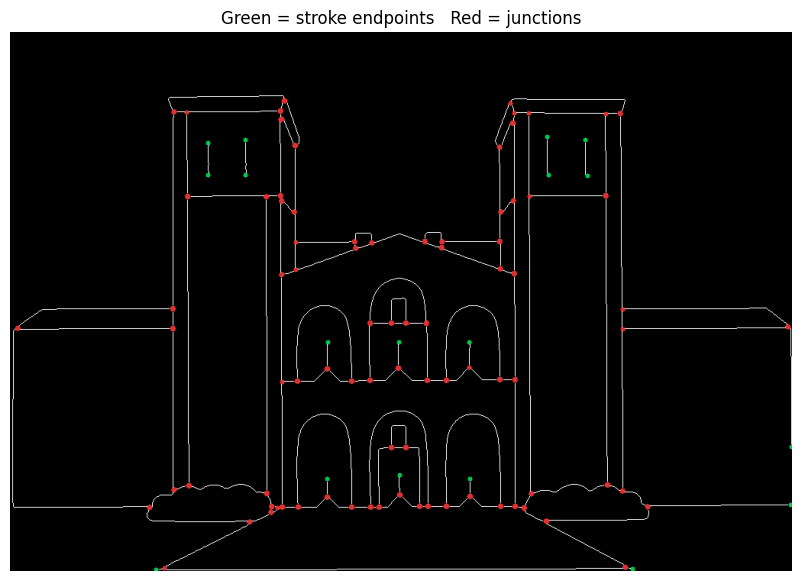

In [17]:
ys, xs = np.where(skeleton > 0)
pixels = set(zip(xs.tolist(), ys.tolist()))

G = nx.Graph()
G.add_nodes_from(pixels)
for (x, y) in pixels:
    for dx in (-1, 0, 1):
        for dy in (-1, 0, 1):
            if dx == dy == 0: continue
            nb = (x+dx, y+dy)
            if nb in pixels: G.add_edge((x,y), nb)

endpoints = [n for n in G.nodes if G.degree(n) == 1]
junctions = set(n for n in G.nodes if G.degree(n) >= 3)
print(f"Nodes: {G.number_of_nodes():,}  |  Edges: {G.number_of_edges():,}")
print(f"Endpoints: {len(endpoints)}   Junctions: {len(junctions)}")

vis = cv2.cvtColor(skeleton, cv2.COLOR_GRAY2RGB)
for (x,y) in endpoints: cv2.circle(vis,(x,y),3,(0,200,80),-1)
for (x,y) in junctions: cv2.circle(vis,(x,y),3,(220,50,50),-1)
plt.figure(figsize=(12,7))
plt.imshow(vis)
plt.title("Green = stroke endpoints   Red = junctions")
plt.axis("off"); plt.show()

## Step 5 — Walk strokes

In [18]:
visited_edges = set()
raw_strokes   = []

def walk_stroke(start, nxt):
    path = [start, nxt]
    visited_edges.add(frozenset([start, nxt]))
    cur, prev = nxt, start
    while True:
        nbs = [n for n in G.neighbors(cur) if n != prev]
        if not nbs or len(nbs) > 1 or cur in junctions: break
        nb = nbs[0]; edge = frozenset([cur, nb])
        if edge in visited_edges: break
        visited_edges.add(edge)
        path.append(nb); prev, cur = cur, nb
    return path

for node in endpoints + list(junctions):
    for nb in G.neighbors(node):
        edge = frozenset([node, nb])
        if edge not in visited_edges:
            s = walk_stroke(node, nb)
            if len(s) >= MIN_STROKE_PX:
                raw_strokes.append(s)

lengths = [len(s) for s in raw_strokes]
print(f"Raw strokes  : {len(raw_strokes)}")
print(f"Length range : {min(lengths)}–{max(lengths)} px   mean: {np.mean(lengths):.1f} px")

Raw strokes  : 132
Length range : 10–604 px   mean: 90.5 px


## Step 6 — Sample dots by arc length

This is the key step. Instead of RDP (which gives only start+end for straight strokes), we walk the actual pixel path and place a dot every `DOT_SPACING` pixels of **cumulative arc length** — like placing evenly-spaced beads on a wire.

Every stroke becomes a proper dotted line with intermediate points.

In [19]:
def sample_dots_by_arc_length(raw_pixels, dot_spacing):
    """
    Place guide dots every `dot_spacing` pixels along the stroke's arc length.

    Args:
        raw_pixels  : list of (x,y) tuples — ordered skeleton pixels
        dot_spacing : distance in pixels between consecutive dots

    Returns:
        List of [x, y] dot positions (always includes first and last point)
    """
    pts = np.array(raw_pixels, dtype=float)

    # Cumulative arc length along the pixel chain
    diffs      = np.diff(pts, axis=0)
    seg_lens   = np.hypot(diffs[:,0], diffs[:,1])
    cum_len    = np.concatenate([[0], np.cumsum(seg_lens)])
    total_len  = cum_len[-1]

    # Stroke too short for even one spacing — just keep endpoints
    if total_len < dot_spacing:
        return [list(map(int, pts[0])), list(map(int, pts[-1]))]

    # Evenly spaced target distances along the arc
    targets = list(np.arange(0, total_len, dot_spacing))
    if targets[-1] < total_len:          # always include the last point
        targets.append(total_len)

    dots = []
    for t in targets:
        # Which segment does this distance fall in?
        idx = min(np.searchsorted(cum_len, t, side='right') - 1, len(pts) - 2)
        seg_len = cum_len[idx+1] - cum_len[idx]
        frac    = (t - cum_len[idx]) / seg_len if seg_len > 0 else 0
        # Linearly interpolate between the two bounding pixels
        interp  = pts[idx] + frac * (pts[idx+1] - pts[idx])
        dots.append([int(round(interp[0])), int(round(interp[1]))])

    return dots


# Apply to all strokes
strokes = []
for i, raw in enumerate(raw_strokes):
    dots = sample_dots_by_arc_length(raw, DOT_SPACING)
    strokes.append({
        "stroke_id"    : i,
        "point_count"  : len(dots),
        "stroke_len_px": int(sum(
            np.hypot(raw[j+1][0]-raw[j][0], raw[j+1][1]-raw[j][1])
            for j in range(len(raw)-1)
        )),
        "points"       : dots
    })

total_dots = sum(s["point_count"] for s in strokes)
print(f"Strokes       : {len(strokes)}")
print(f"Total dots    : {total_dots}  at {DOT_SPACING}px spacing")
print(f"Dots/stroke   : {total_dots/len(strokes):.1f} avg")

# Spacing sensitivity table
print("\nSpacing vs dot count:")
for sp in [8, 12, 15, 20, 30]:
    n = sum(len(sample_dots_by_arc_length(r, sp)) for r in raw_strokes)
    bar = '█' * (n // 50)
    print(f"  spacing={sp:>2}px  →  {n:>4} dots  {bar}")

Strokes       : 132
Total dots    : 1021  at 15px spacing
Dots/stroke   : 7.7 avg

Spacing vs dot count:
  spacing= 8px  →  1739 dots  ██████████████████████████████████
  spacing=12px  →  1217 dots  ████████████████████████
  spacing=15px  →  1021 dots  ████████████████████
  spacing=20px  →   812 dots  ████████████████
  spacing=30px  →   609 dots  ████████████


## Step 7 — Visualize dotted strokes

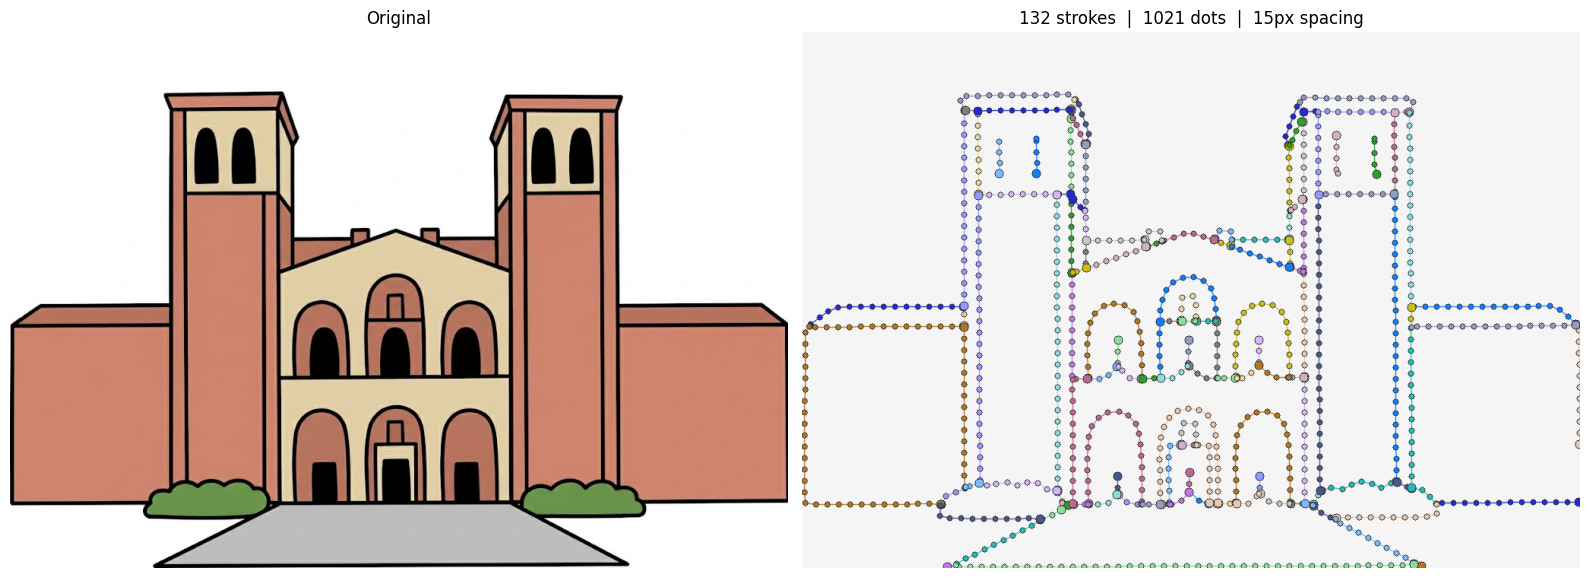

Saved → guide_dots_preview.png


In [20]:
cmap   = matplotlib.colormaps.get_cmap("tab20")
canvas = np.ones((H, W, 3), dtype=np.uint8) * 245

for idx, stroke in enumerate(strokes):
    color = tuple(int(c*255) for c in cmap(idx % 20)[:3])
    pts   = stroke["points"]

    # Faint connecting line (the intended path)
    for j in range(len(pts) - 1):
        cv2.line(canvas, tuple(pts[j]), tuple(pts[j+1]),
                 tuple(reversed(color)), 1, cv2.LINE_AA)

    # Guide dots — first dot slightly bigger to show stroke start
    for j, (px, py) in enumerate(pts):
        r = 6 if j == 0 else 4
        cv2.circle(canvas, (px, py), r, tuple(reversed(color)), -1)
        cv2.circle(canvas, (px, py), r, (50, 50, 50), 1)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
axes[0].imshow(img_rgb)
axes[0].set_title("Original"); axes[0].axis("off")
axes[1].imshow(canvas)
axes[1].set_title(f"{len(strokes)} strokes  |  {total_dots} dots  |  {DOT_SPACING}px spacing")
axes[1].axis("off")
plt.tight_layout()
plt.savefig("guide_dots_preview.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → guide_dots_preview.png")

## Step 8 — Overlay on original

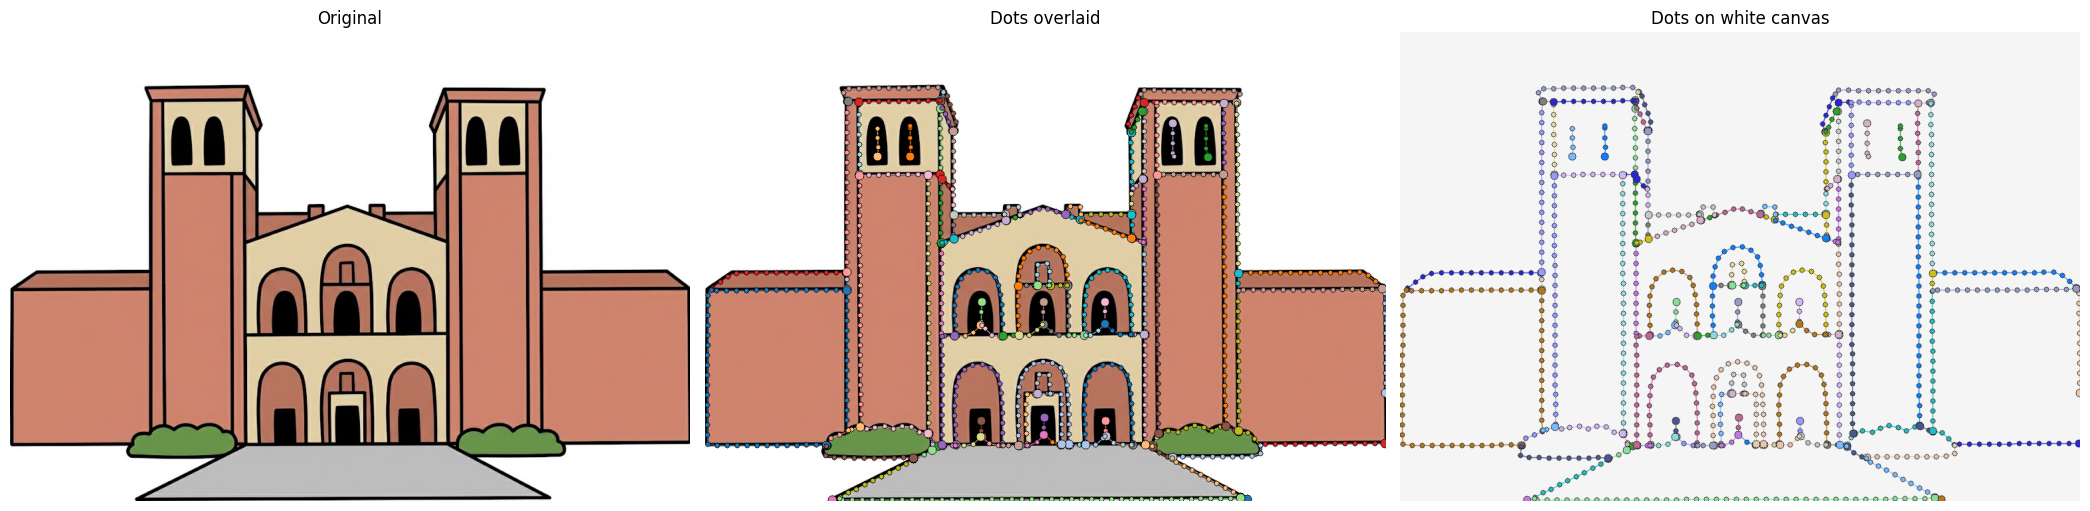

In [21]:
overlay = img_rgb.copy()
for idx, stroke in enumerate(strokes):
    color = tuple(int(c*255) for c in cmap(idx % 20)[:3])
    pts   = stroke["points"]
    for j in range(len(pts)-1):
        cv2.line(overlay, tuple(pts[j]), tuple(pts[j+1]), color, 1, cv2.LINE_AA)
    for j, (px, py) in enumerate(pts):
        r = 7 if j == 0 else 4
        cv2.circle(overlay, (px, py), r, color, -1)
        cv2.circle(overlay, (px, py), r, (0, 0, 0), 1)

fig, axes = plt.subplots(1, 3, figsize=(21, 6))
axes[0].imshow(img_rgb);  axes[0].set_title("Original");             axes[0].axis("off")
axes[1].imshow(overlay);  axes[1].set_title("Dots overlaid");        axes[1].axis("off")
axes[2].imshow(canvas);   axes[2].set_title("Dots on white canvas"); axes[2].axis("off")
plt.tight_layout(); plt.show()

## Step 9 — Export JSON

In [22]:
output = {
    "image"        : INPUT_IMAGE,
    "mode"         : mode,
    "image_width"  : W,
    "image_height" : H,
    "dot_spacing"  : DOT_SPACING,
    "stroke_count" : len(strokes),
    "total_dots"   : total_dots,
    "strokes"      : strokes
}

with open(OUTPUT_JSON, "w") as f:
    json.dump(output, f, indent=2)

print(f"Saved → {OUTPUT_JSON}")
print(f"\nJSON schema:")
print(f"  image_width / image_height   →  canvas size to normalise coords")
print(f"  dot_spacing                  →  pixels between dots (for reference)")
print(f"  strokes[i].stroke_id         →  draw order index")
print(f"  strokes[i].points            →  [[x,y], ...] evenly spaced along stroke")
print(f"  strokes[i].point_count       →  number of dots in this stroke")
print(f"  strokes[i].stroke_len_px     →  total arc length of this stroke")
print()
for s in strokes[:5]:
    print(f"  stroke {s['stroke_id']:>3}: {s['point_count']:>3} dots  "
          f"arc={s['stroke_len_px']}px  "
          f"first={s['points'][0]}  last={s['points'][-1]}")

Saved → strokes.json

JSON schema:
  image_width / image_height   →  canvas size to normalise coords
  dot_spacing                  →  pixels between dots (for reference)
  strokes[i].stroke_id         →  draw order index
  strokes[i].points            →  [[x,y], ...] evenly spaced along stroke
  strokes[i].point_count       →  number of dots in this stroke
  strokes[i].stroke_len_px     →  total arc length of this stroke

  stroke   0:   2 dots  arc=9px  first=[815, 703]  last=[806, 701]
  stroke   1:  12 dots  arc=159px  first=[1023, 543]  last=[1019, 386]
  stroke   2:   5 dots  arc=47px  first=[308, 187]  last=[308, 141]
  stroke   3:   4 dots  arc=44px  first=[259, 187]  last=[259, 145]
  stroke   4:   5 dots  arc=48px  first=[756, 188]  last=[753, 141]
